In [32]:
import os
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from herbie import Herbie

# Desactivar advertencias de cfgrib/xarray
warnings.filterwarnings('ignore', category=UserWarning)

# 1. Configuración Geográfica OAQ
LAT_OAQ = -0.2150
LON_OAQ = -78.5025

# 2. Parámetros de la simulación piloto
fecha_run = pd.Timestamp("2026-05-10 00:00")
lead_times = list(range(0, 25, 3)) # [0, 3, 6, 9, 12, 15, 18, 21, 24]

# 3. Diccionario de variables seleccionadas de la Subfase 3B
variables_gfs = {
    "RH700": ("RH", "700 mb"),
    "RH500": ("RH", "500 mb"),
    "T700": ("TMP", "700 mb"),
    "T500": ("TMP", "500 mb"),
    "U700": ("UGRD", "700 mb"),
    "V700": ("VGRD", "700 mb"),
    "Omega700": ("VVEL", "700 mb"),
    "PWAT": ("PWAT", None), # Corrección: es mejor definir explícitamente el nivel
    "TCC": ("TCDC", "entire atmosphere"),
    "HCC": ("HCDC", None)
}

In [33]:
def extraer_variable_oaq(herbie_obj, variable, nivel=None):
    """
    Extrae e interpola linealmente una variable de Herbie sobre el OAQ
    manejando las excepciones de hypercubes y metadatos de proyección.
    """
    lon_oaq_gfs = LON_OAQ % 360
    patron = f":{variable}:" if nivel is None else f":{variable}:{nivel}:"

    try:
        ds = herbie_obj.xarray(patron)

        # Manejo de múltiples hypercubes devueltos como lista (Ej: TCC)
        if isinstance(ds, list):
            # Usar el primero o último que contenga la dimensión meteorológica real
            ds = ds[-1]

        # FILTRO CRÍTICO: Evitar seleccionar 'gribfile_projection' como variable
        vars_validas = [v for v in ds.data_vars if v != 'gribfile_projection']
        if not vars_validas:
            return np.nan
        nombre_var = vars_validas[0]
        
        da = ds[nombre_var]

        # Si persisten dimensiones duplicadas/huérfanas por step, tomamos el primer índice
        if 'step' in da.coords and da.ndim > 2:
            da = da.isel(step=0)

        # Interpolación bilineal
        valor_interpolado = da.interp(latitude=LAT_OAQ, longitude=lon_oaq_gfs, method='linear')
        return float(valor_interpolado.values)

    except Exception as e:
        print(f"   ⚠️ Error en {variable} ({nivel}): {e}")
        return np.nan

In [19]:
def extraer_variable_oaq(herbie_obj, variable, nivel=None):
    """
    Extrae e interpola linealmente una variable específica de un objeto Herbie
    sobre las coordenadas del Observatorio Astronómico de Quito (OAQ).
    """

    lon_oaq_gfs = LON_OAQ % 360

    patron = f":{variable}:" if nivel is None else f":{variable}:{nivel}:"

    ds = herbie_obj.xarray(patron)

    # Algunos campos GFS pueden devolver múltiples hypercubes
    if isinstance(ds, list):
        print(f"Advertencia: {variable} devolvió {len(ds)} datasets. Usando el último.")
        ds = ds[-1]

    nombre_var = list(ds.data_vars)[0]

    valor_interpolado = ds[nombre_var].interp(
        latitude=LAT_OAQ,
        longitude=lon_oaq_gfs
    )

    return float(valor_interpolado.values)

In [26]:
# CELDA 7: PRUEBA PILOTO PARA RH700
rh700_series = []

for fxx in lead_times:
    print(f"Procesando F{fxx:03d}")
    H = Herbie(fecha_run, model="gfs", product="pgrb2.0p25", fxx=fxx)
    
    rh700 = extraer_variable_oaq(H, variable="RH", nivel="700 mb")
    rh700_series.append({"fxx": fxx, "RH700": rh700})

df_rh700 = pd.DataFrame(rh700_series)
df_rh700

Procesando F000
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local
Procesando F003
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F03 ┊ GRIB2 @ aws ┊ IDX @ local
Procesando F006
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ local
Procesando F009
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F09 ┊ GRIB2 @ aws ┊ IDX @ local
Procesando F012
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F12 ┊ GRIB2 @ aws ┊ IDX @ local
Procesando F015
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F15 ┊ GRIB2 @ aws ┊ IDX @ local
Procesando F018
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F18 ┊ GRIB2 @ aws ┊ IDX @ local
Procesando F021
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F21 ┊ GRIB2 @ aws ┊ IDX @ local
Procesando F024
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F24 ┊ GRIB2 @ a

,fxx,RH700
0,0,78.060140
1,3,79.197498
2,6,69.609101
3,9,71.224497
4,12,68.665438
5,15,57.669478
6,18,59.014141
7,21,60.857062
8,24,70.851222


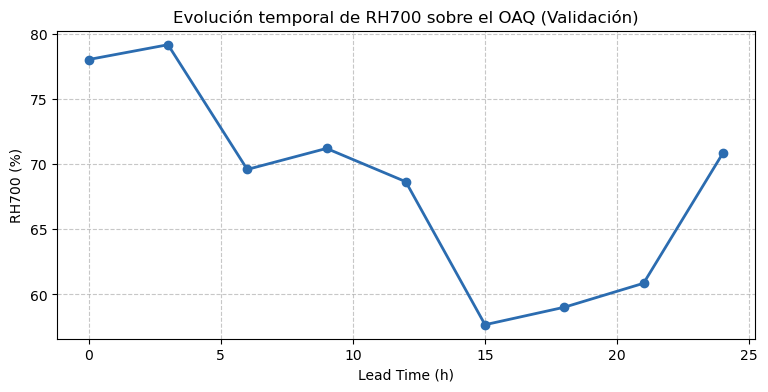

In [ ]:

plt.figure(figsize=(9, 4))
plt.plot(df_rh700["fxx"], df_rh700["RH700"], marker="o", color="#2b6cb0", linewidth=2)
plt.xlabel("Lead Time (h)")
plt.ylabel("RH700 (%)")
plt.title("Evolución temporal de RH700 sobre el OAQ (Validación)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [28]:

valid_times = [fecha_run + pd.Timedelta(hours=fxx) for fxx in lead_times]
df_tiempos = pd.DataFrame({"fxx": lead_times, "valid_time": valid_times})
df_tiempos

,fxx,valid_time
0,0,2026-05-10 00:00:00
1,3,2026-05-10 03:00:00
2,6,2026-05-10 06:00:00
3,9,2026-05-10 09:00:00
4,12,2026-05-10 12:00:00
5,15,2026-05-10 15:00:00
6,18,2026-05-10 18:00:00
7,21,2026-05-10 21:00:00
8,24,2026-05-11 00:00:00


In [34]:
gfs_series = []

for fxx in lead_times:
    print(f"\n Procesando Lead Time F{fxx:03d}...")
    
    # 1. Una sola llamada a Herbie por paso temporal
    H = Herbie(fecha_run, model="gfs", product="pgrb2.0p25", fxx=fxx)
    
    # Inicializar la fila con los datos de tiempo de válido
    fila = {
        "valid_time": fecha_run + pd.Timedelta(hours=fxx),
        "fxx": fxx
    }
    
    # 2. Extraer las 10 variables eficientemente
    for nombre, (variable, nivel) in variables_gfs.items():
        fila[nombre] = extraer_variable_oaq(H, variable=variable, nivel=nivel)
        
    gfs_series.append(fila)

# 3. Construcción del DataFrame Final GFS_OAQ(t)
df_gfs = pd.DataFrame(gfs_series)
df_gfs


 Procesando Lead Time F000...
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local

 Procesando Lead Time F003...
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F03 ┊ GRIB2 @ aws ┊ IDX @ local
Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.

 Procesando Lead Time F006...
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F06 ┊ GRIB2 @ aws ┊ IDX @ local
Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.

 Procesando Lead Time F009...
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F09 ┊ GRIB2 @ aws ┊ IDX @ local
Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.

 Procesando Lead Time F012...
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-May-10 00:00 UTC F12 ┊ GRIB2 @ aws ┊ IDX @ local
Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multi

,valid_time,fxx,RH700,RH500,T700,T500,U700,V700,Omega700,PWAT,TCC,HCC
0,2026-05-10 00:00:00,0,78.060140,57.593201,286.109543,269.999630,-0.265269,-1.151819,-0.206281,19.682743,97.691800,95.030680
1,2026-05-10 03:00:00,3,79.197498,56.951321,283.868218,269.460351,-2.172725,0.594900,-0.129712,17.472410,97.795418,80.999923
2,2026-05-10 06:00:00,6,69.609101,58.920961,283.534695,269.255802,-2.405247,1.319288,-0.012226,15.479798,94.979337,16.090700
3,2026-05-10 09:00:00,9,71.224497,57.305701,282.473030,269.218691,-2.524555,1.728674,0.061082,14.929671,39.874161,90.785640
4,2026-05-10 12:00:00,12,68.665438,65.132637,283.055647,268.627154,-2.877671,1.381528,0.039743,15.363532,54.620301,75.574083
5,2026-05-10 15:00:00,15,57.669478,68.991583,286.627341,268.230513,-2.598111,-0.186815,-0.188108,16.862818,40.179918,69.798261
6,2026-05-10 18:00:00,18,59.014141,63.291817,287.207836,268.902219,-2.348386,-0.270354,-0.537738,17.854949,62.064660,30.642341
7,2026-05-10 21:00:00,21,60.857062,69.025502,287.646510,269.128496,-1.289884,-3.600690,-0.581550,18.814160,83.117122,19.669040
8,2026-05-11 00:00:00,24,70.851222,76.857460,285.628141,268.573849,-1.800031,-1.777896,-0.463290,18.881070,68.903017,5.018900


In [36]:
print(f"Dimensiones del Dataset: {df_gfs.shape}")
print(f"Valores nulos detectados: {df_gfs.isnull().sum().sum()}")
df_gfs.describe().T

Dimensiones del Dataset: (9, 12)
Valores nulos detectados: 0


,count,mean,min,25%,50%,75%,max,std
valid_time,9,2026-05-10 12:00:00,2026-05-10 00:00:00,2026-05-10 06:00:00,2026-05-10 12:00:00,2026-05-10 18:00:00,2026-05-11 00:00:00,NaN
fxx,9.0,12.0,0.0,6.0,12.0,18.0,24.0,8.215838
RH700,9.0,68.349842,57.669478,60.857062,69.609101,71.224497,79.197498,7.790496
RH500,9.0,63.785576,56.951321,57.593201,63.291817,68.991583,76.85746,6.875661
T700,9.0,285.127885,282.47303,283.534695,285.628141,286.627341,287.64651,1.923519
T500,9.0,269.044078,268.230513,268.627154,269.128496,269.255802,269.99963,0.52983
U700,9.0,-2.03132,-2.877671,-2.524555,-2.348386,-1.800031,-0.265269,0.811122
V700,9.0,-0.218132,-3.60069,-1.151819,-0.186815,1.319288,1.728674,1.736508
Omega700,9.0,-0.224231,-0.58155,-0.46329,-0.188108,-0.012226,0.061082,0.247413
PWAT,9.0,17.260128,14.929671,15.479798,17.47241,18.81416,19.682743,1.719954
